In [1]:
# Run through the post estimate tests tomorrow

# Survival Analysis

## 1. Import Packages

In [2]:
!conda install -c sebp scikit-survival --yes 
!pip install lifelines
!pip install xgbse

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl

from sksurv.nonparametric import kaplan_meier_estimator # Library for survival analysis
from sksurv.nonparametric import kaplan_meier_estimator # Load the necessary package
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
# importing model and utils from xgbse
from xgbse.converters import convert_to_structured

# importing metrics
from xgbse.metrics import (
    concordance_index,
    approx_brier_score
)

from sksurv.util import Surv
from sksurv.metrics import cumulative_dynamic_auc

import shap

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# importing model and utils from xgbse
from xgbse import (XGBSEKaplanNeighbors, 
                   XGBSEDebiasedBCE,
                   XGBSEKaplanTree,
                   XGBSEStackedWeibull,
                   XGBSEBootstrapEstimator)

from xgbse.converters import convert_to_structured

# importing metrics
from xgbse.metrics import (
    concordance_index,
    approx_brier_score,
    dist_calibration_score
)


Channels:
 - sebp
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [3]:
def summarize_dataframe(df):
    """Summarize a dataframe, and report missing values."""
    missing_values = pd.concat([pd.DataFrame(df.columns, columns=['Variable Name']), 
                      pd.DataFrame(df.dtypes.values.reshape([-1,1]), columns=['Data Type']),
                      pd.DataFrame(df.isnull().sum().values, columns=['Missing Values']), 
                      pd.DataFrame([df[name].nunique() for name in df.columns], columns=['Unique Values'])], 
                     axis=1).set_index('Variable Name')
    with pd.option_context("display.max_rows", 1000):
        display(pd.concat([missing_values, df.describe(include='all').transpose()], axis=1).fillna(""))

## 2. Read and View the Data

In [ ]:
data = pd.read_csv('03_Analysis/clean_data_7-9-26_9-47-PM.csv.gz')

In [5]:
summarize_dataframe(data)

/tmp/ipykernel_3282/168232490.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  display(pd.concat([missing_values, df.describe(include='all').transpose()], axis=1).fillna(""))


,Data Type,Missing Values,Unique Values,count,unique,top,freq,mean,std,min,25%,50%,75%,max
acn,int64,0,33723,33723.0,,,,1828811.478783,192110.173434,1507557.0,1673862.5,1806271.0,1981117.5,2296796.0
event_date,object,0,84,33723.0,84,2019-11-01,622,,,,,,,
narrative_text,object,0,33715,33723.0,33715,The UAS lost the telemetry link 1;300 feet fro...,3,,,,,,,
synopsis,object,1,33668,33722.0,33668,Part 107 UAS pilot reported flying in controll...,9,,,,,,,
word_count,int64,0,1306,33723.0,,,,261.27207,216.912553,2.0,119.0,205.0,334.0,2345.0
hedge_score,float64,0,2537,33723.0,,,,0.002822,0.004726,0.0,0.0,0.0,0.004545,0.142857
passive_voice_ratio,float64,0,632,33723.0,,,,0.183942,0.170208,0.0,0.0588,0.15,0.2667,1.0
causal_connective_count,int64,0,17,33723.0,,,,0.704801,1.17733,0.0,0.0,0.0,1.0,20.0
specificity_score,float64,0,5,33723.0,,,,0.27244,0.223232,0.0,0.0,0.25,0.5,1.0
named_entity_count,int64,0,113,33723.0,,,,13.275094,11.897187,0.0,5.0,10.0,18.0,144.0


In [6]:
# Convert to actual datetime dtype
data['event_date'] = pd.to_datetime(data['event_date'])

# Confirm the conversion worked
print(data['event_date'].dtype)  # should now show datetime64[ns]

datetime64[ns]


In [7]:
# For right censored data, days_to_recurrence needs to be filled since typically the time variable in survival analysis is days since last observation

# Reference dates
cutoff_2023 = pd.Timestamp('2023-12-31')
study_end = pd.Timestamp('2024-12-31')

# Only touch rows where days_to_recurrence is currently null
mask_null = data['days_to_recurrence'].isna()

# Case 1: event_date on or before 12/31/2023 -> full 365-day window observed
mask_full_window = mask_null & (data['event_date'] <= cutoff_2023)
data.loc[mask_full_window, 'days_to_recurrence'] = 365

# Case 2: event_date after 12/31/2023 -> truncated window, days until study end
mask_truncated = mask_null & (data['event_date'] > cutoff_2023)
data.loc[mask_truncated, 'days_to_recurrence'] = (study_end - data.loc[mask_truncated, 'event_date']).dt.days

# Sanity checks
print(data['days_to_recurrence'].isna().sum())   # should be 0
print((data['days_to_recurrence'] < 0).sum())    # should be 0

0
0


## 3. Survival Analysis

### 3.1 Cox Proportional Hazard Model Using Only Linguistic Factors

In [8]:
# Have to filter out any ZZZ due to compromise of recurrence definition and shuffling with random seed 1
filtered_data = data[data['airport'] != 'ZZZ'].dropna(subset=['self_score', 'actual_severity', 'potential_severity'])

df = filtered_data[[
           'hedge_score',
           'passive_voice_ratio',
           'causal_connective_count',
           'specificity_score',
           'type_token_ratio',
           'self_score',
           'actual_severity',
           'potential_severity',
           'recurrence_flag',
           'days_to_recurrence']
    ].sample(frac=1,random_state=1) # Shuffles the data with a random seed of 1

# removing: word_count, named_entity_count, is_right_censored due to collinearity issues flagged in correlation matrix

summarize_dataframe(df)

,Data Type,Missing Values,Unique Values,count,mean,std,min,25%,50%,75%,max
hedge_score,float64,0,1405,11145.0,0.002918,0.004997,0.0000,0.0000,0.0000,0.004717,0.142857
passive_voice_ratio,float64,0,343,11145.0,0.177634,0.161413,0.0000,0.0556,0.1500,0.250000,1.000000
causal_connective_count,int64,0,14,11145.0,0.678331,1.132936,0.0000,0.0000,0.0000,1.000000,14.000000
specificity_score,float64,0,5,11145.0,0.300067,0.225552,0.0000,0.2500,0.2500,0.500000,1.000000
type_token_ratio,float64,0,3496,11145.0,0.544943,0.128957,0.2203,0.4540,0.5273,0.619400,1.000000
self_score,float64,0,2,11145.0,0.198654,0.399005,0.0000,0.0000,0.0000,0.000000,1.000000
actual_severity,float64,0,5,11145.0,1.415792,0.550176,1.0000,1.0000,1.0000,2.000000,5.000000
potential_severity,float64,0,5,11145.0,3.527052,0.941300,1.0000,3.0000,4.0000,4.000000,5.000000
recurrence_flag,int64,0,2,11145.0,0.061911,0.241005,0.0000,0.0000,0.0000,0.000000,1.000000
days_to_recurrence,float64,0,44,11145.0,329.489547,86.195195,28.0000,365.0000,365.0000,365.000000,365.000000


In [35]:
# Check the balance of the target variable
recurrence = df.recurrence_flag.value_counts()
print('Class Counts')
print(recurrence)
print('=========')
print('Recurrence Rate')
print(recurrence[1] / recurrence[0])

Class Counts
recurrence_flag
0    10455
1      690
Name: count, dtype: int64
Recurrence Rate
0.06599713055954089


In [10]:
# Splits the shuffled data into train and test data

train = df.head(round(11145*.8))
test = df.tail(round(11145*.2))

# Scaling continuous cols after splitting - leaving out self score (binary categorical) and the potential and acutal severity scores (ordinals)

continuous_cols = [
    'causal_connective_count',  # counts
    'hedge_score', 'passive_voice_ratio', 'specificity_score', 'type_token_ratio',  # ratios
]

std_scaler = StandardScaler()

scaled_train = train.copy()
scaled_test = test.copy()

scaled_train[continuous_cols] = std_scaler.fit_transform(train[continuous_cols])
scaled_test[continuous_cols] = std_scaler.transform(test[continuous_cols])

In [11]:
cph = CoxPHFitter()   # Instantiate the class to create a cph object
cph.fit(scaled_train, 'days_to_recurrence', event_col='recurrence_flag')   # Fit the data to train the model
cph.print_summary()    # Have a look at the significance of the features

<lifelines.CoxPHFitter: fitted with 8916 total observations, 8368 right-censored observations>
             duration col = 'days_to_recurrence'
                event col = 'recurrence_flag'
      baseline estimation = breslow
   number of observations = 8916
number of events observed = 548
   partial log-likelihood = -4916.64
         time fit was run = 2026-07-22 19:42:11 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
hedge_score             -0.02      0.98      0.04           -0.10            0.07                0.91                1.07
passive_voice_ratio      0.01      1.01      0.04           -0.07            0.09                0.93                1.09
causal_connective_count  0.00      1.00      0.05           -0.10            0.10                0.91                1.10
specificity_score       -0.07      0.94      0.05           -0.16            0.03                0.85                1.03
type_token_ratio         0.13      1.14      0.05            0.04            0.23                1.04                1.26
self_score              -0.50      0.61      0.14           -0.76           -0.23                0.47                0.80
actual_severity         -0.09      0.91      0.08           -0.25            0.07                0.78                1.08
potential_severity       0.02      1.02      0.05           -0.07            0.11                0.93                1.12

                         cmp to     z      p  -log2(p)
covariate                                             
hedge_score                0.00 -0.39   0.70      0.52
passive_voice_ratio        0.00  0.20   0.84      0.25
causal_connective_count    0.00  0.01   0.99      0.01
specificity_score          0.00 -1.39   0.16      2.61
type_token_ratio           0.00  2.79   0.01      7.58
self_score                 0.00 -3.64 <0.005     11.82
actual_severity            0.00 -1.07   0.28      1.82
potential_severity         0.00  0.43   0.67      0.59
---
Concordance = 0.58
Partial AIC = 9849.28
log-likelihood ratio test = 42.49 on 8 df
-log2(p) of ll-ratio test = 19.80

In [12]:
test_Labels = convert_to_structured(scaled_test['days_to_recurrence'], scaled_test['recurrence_flag'])

pred = cph.predict_survival_function(scaled_test)

print(f'C-index: {concordance_index(test_Labels, pred.T)}')
print(f'Avg. Brier Score: {approx_brier_score(test_Labels, pred.T)}')

C-index: 0.586490300701364
Avg. Brier Score: 0.037214688667786766


/opt/conda/lib/python3.12/site-packages/xgbse/non_parametric.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return pd.DataFrame(C_exp).fillna(method="bfill").fillna(method="ffill").values


### 3.2 Tree Based Survival Models Using Only Linguistic Factors

In [ ]:

# Splitting train and test data and removing word count and named entity count
trainData = df[[
           'hedge_score',
           'passive_voice_ratio',
           'causal_connective_count',
           'specificity_score',
           'type_token_ratio',
           'self_score',
           'actual_severity',
           'potential_severity']].head(round(11145*.8))

trainLabels = df[['days_to_recurrence','recurrence_flag']].head(round(11145*.8))

testData = df[[
           'hedge_score',
           'passive_voice_ratio',
           'causal_connective_count',
           'specificity_score',
           'type_token_ratio',
           'self_score',
           'actual_severity',
           'potential_severity']].tail(round(11145*.2))

testLabels = df[['days_to_recurrence','recurrence_flag']].tail(round(11145*.2))

scaler = MinMaxScaler()

trainData = pd.DataFrame(scaler.fit_transform(trainData), 
                         columns=trainData.columns)

testData = pd.DataFrame(scaler.transform(testData), 
                         columns=testData.columns)

X = trainData
y = convert_to_structured(trainLabels['days_to_recurrence'], trainLabels['recurrence_flag'])

X_val = testData
y_val = convert_to_structured(testLabels['days_to_recurrence'], testLabels['recurrence_flag'])

In [14]:
# fitting xgbse Kaplan Neieighbghbors model
kaplan_xgbse_model = XGBSEKaplanNeighbors(n_neighbors=5)
kaplan_xgbse_model.fit(
    X, y,
    validation_data=(X_val, y_val),
    early_stopping_rounds=20,  # Stops training if validation metric doesn't improve for 20 rounds
    verbose_eval=False  # Prints the evaluation metric on the validation set
)

# predicting
preds = kaplan_xgbse_model.predict(X_val)

# # running metrics
print(f'C-index: {concordance_index(y_val, preds)}')
print(f'Avg. Brier Score: {approx_brier_score(y_val, preds)}')

/opt/conda/lib/python3.12/site-packages/xgbse/non_parametric.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return pd.DataFrame(C_exp).fillna(method="bfill").fillna(method="ffill").values


C-index: 0.6082043984476068
Avg. Brier Score: 0.04100959712346765


/opt/conda/lib/python3.12/site-packages/xgbse/non_parametric.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return pd.DataFrame(C_exp).fillna(method="bfill").fillna(method="ffill").values


In [15]:
# fitting xgbse Debiased BCE model
debiased_xgbse_model = XGBSEDebiasedBCE()
debiased_xgbse_model.fit(
    X, y,
    validation_data=(X_val, y_val),
    early_stopping_rounds=20,  # Stops training if validation metric doesn't improve for 20 rounds
    verbose_eval=False  # Prints the evaluation metric on the validation set
)

# predicting
preds = debiased_xgbse_model.predict(X_val)

# # running metrics
print(f'C-index: {concordance_index(y_val, preds)}')
print(f'Avg. Brier Score: {approx_brier_score(y_val, preds)}')

C-index: 0.6813945666235446
Avg. Brier Score: 0.03902458166672751


/opt/conda/lib/python3.12/site-packages/xgbse/non_parametric.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return pd.DataFrame(C_exp).fillna(method="bfill").fillna(method="ffill").values


In [16]:
# fitting xgbse Stacked Weibull Bootstrap Estimator model

base = XGBSEStackedWeibull()
bootstrapped_xgbse_model = XGBSEBootstrapEstimator(base_estimator = base,
                                      n_estimators = 5,
                                      random_state = 1)
bootstrapped_xgbse_model.fit(
    X, y,
    validation_data=(X_val, y_val),
    early_stopping_rounds=20,  # Stops training if validation metric doesn't improve for 20 rounds
    verbose_eval=False  # Prints the evaluation metric on the validation set
)

# predicting
preds = bootstrapped_xgbse_model.predict(X_val)

# # running metrics
print(f'C-index: {concordance_index(y_val, preds)}')
print(f'Avg. Brier Score: {approx_brier_score(y_val, preds)}')

C-index: 0.7584588184562311
Avg. Brier Score: 0.03576917277496922


/opt/conda/lib/python3.12/site-packages/xgbse/non_parametric.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return pd.DataFrame(C_exp).fillna(method="bfill").fillna(method="ffill").values


In [17]:
# fitting xgbse Stacked Weibull model

stacked_xgbse_model = XGBSEStackedWeibull()
stacked_xgbse_model.fit(
    X, y,
    validation_data=(X_val, y_val),
    early_stopping_rounds=20,  # Stops training if validation metric doesn't improve for 20 rounds
    verbose_eval=False  # Prints the evaluation metric on the validation set
)

# predicting
preds = stacked_xgbse_model.predict(X_val)

# # running metrics
print(f'C-index: {concordance_index(y_val, preds)}')
print(f'Avg. Brier Score: {approx_brier_score(y_val, preds)}')

C-index: 0.6842363087537732
Avg. Brier Score: 0.03841144211400321


/opt/conda/lib/python3.12/site-packages/xgbse/non_parametric.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return pd.DataFrame(C_exp).fillna(method="bfill").fillna(method="ffill").values


## 4. Interpreting the Models

### 4.1 Looking at Top Performing Model

In [18]:
# Getting Feature Importances

importances = []
for est in bootstrapped_xgbse_model.estimators_:
    importances.append(est.feature_importances_)

imp_df = pd.DataFrame(importances).fillna(0)
mean_importance = imp_df.mean().sort_values(ascending=False)
print(mean_importance)

type_token_ratio           69.8
hedge_score                50.0
passive_voice_ratio        50.0
specificity_score          19.4
potential_severity         16.2
causal_connective_count    15.2
actual_severity            11.2
self_score                  4.4
dtype: float64


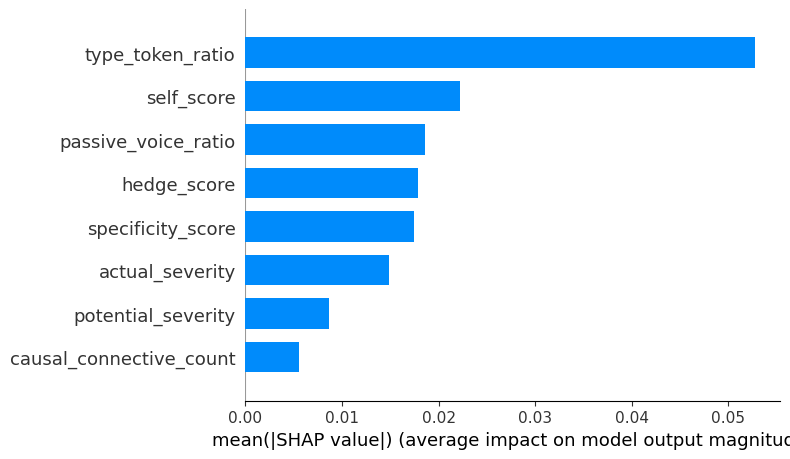

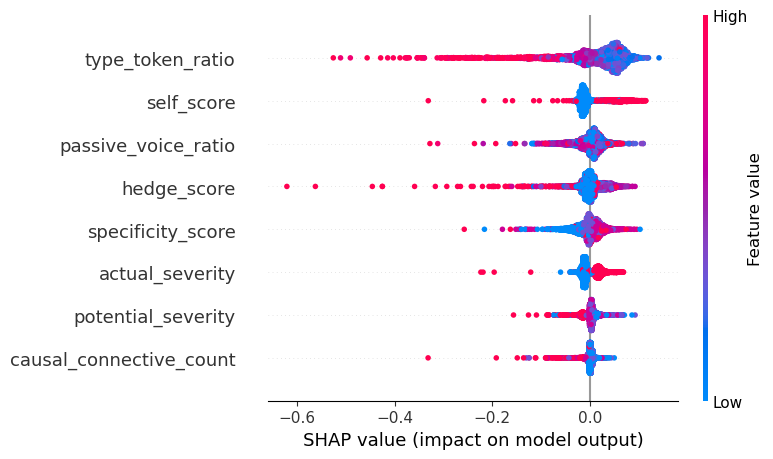

In [19]:
# Getting SHAP Values

all_shap_values = []

for est in bootstrapped_xgbse_model.estimators_:
    explainer = shap.TreeExplainer(est.feature_extractor.bst)
    sv = explainer.shap_values(X_val)
    all_shap_values.append(sv)

mean_shap_values = np.mean(all_shap_values, axis=0)

# Ranked magnitude (comparable to your gain importance table)
shap.summary_plot(mean_shap_values, X_val, plot_type="bar")

# Full beeswarm — adds direction (does high hedge_score push risk up or down?)
shap.summary_plot(mean_shap_values, X_val)

### 4.2 Looking at All XGB Models Together

/opt/conda/lib/python3.12/site-packages/xgbse/non_parametric.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return pd.DataFrame(C_exp).fillna(method="bfill").fillna(method="ffill").values
/opt/conda/lib/python3.12/site-packages/xgbse/non_parametric.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return pd.DataFrame(C_exp).fillna(method="bfill").fillna(method="ffill").values
/opt/conda/lib/python3.12/site-packages/xgbse/non_parametric.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return pd.DataFrame(C_exp).fillna(method="bfill").fillna(method="ffill").values
/opt/conda/lib/python3.12/site-packages/xgbse/non_parametric.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise

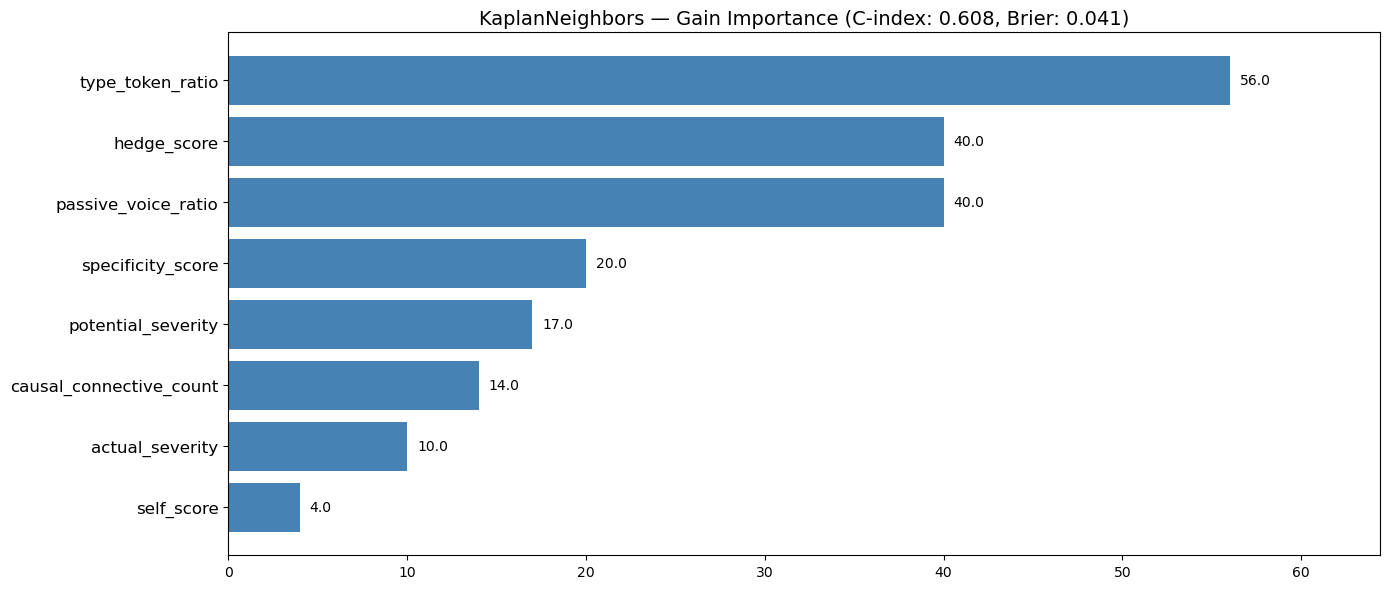

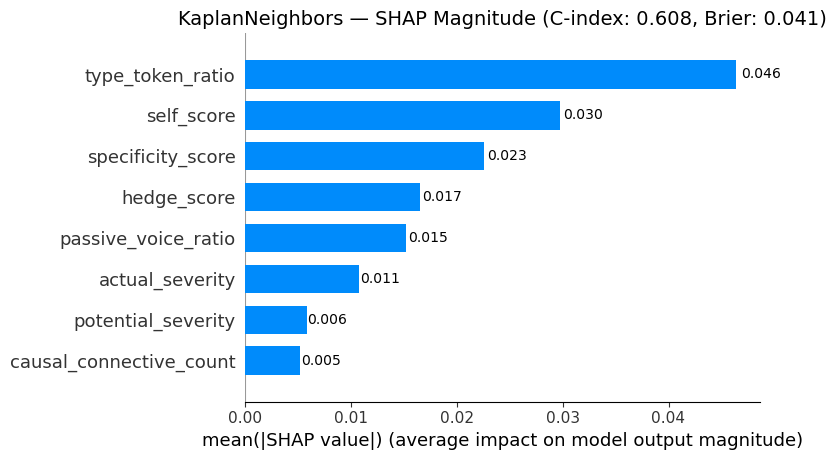

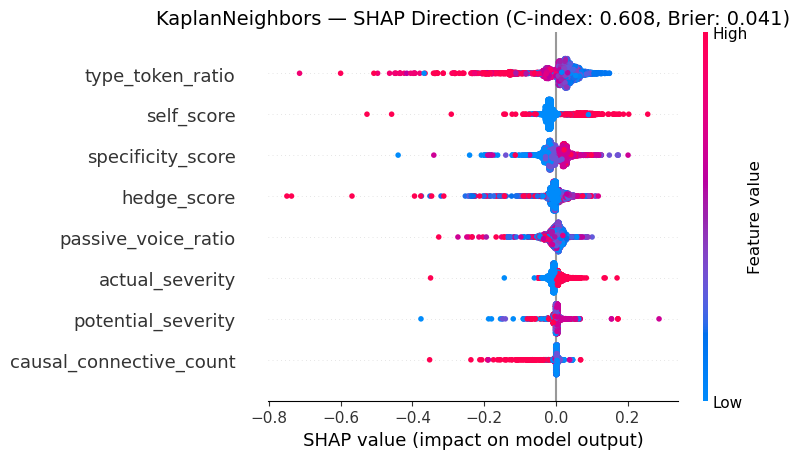

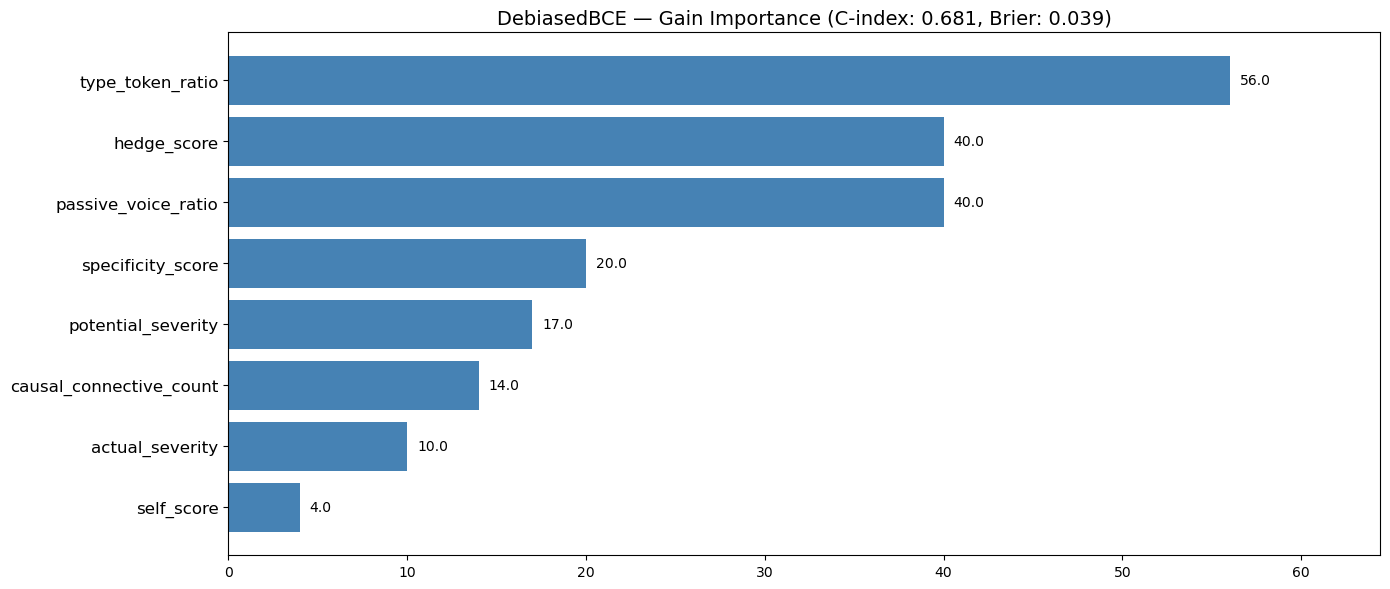

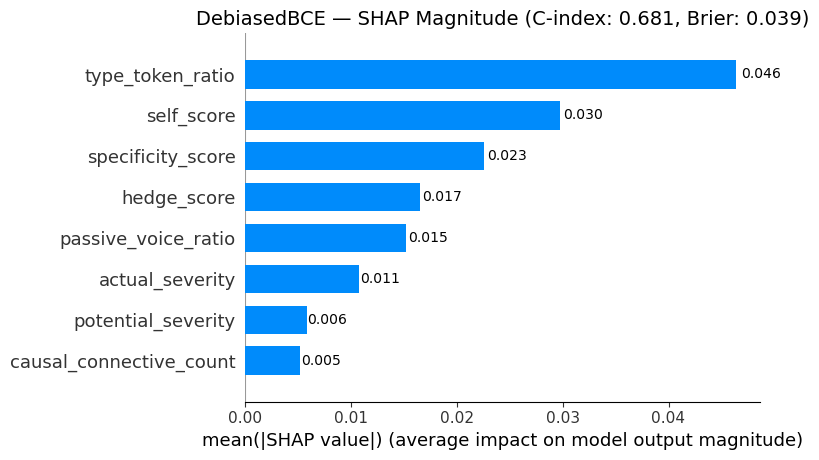

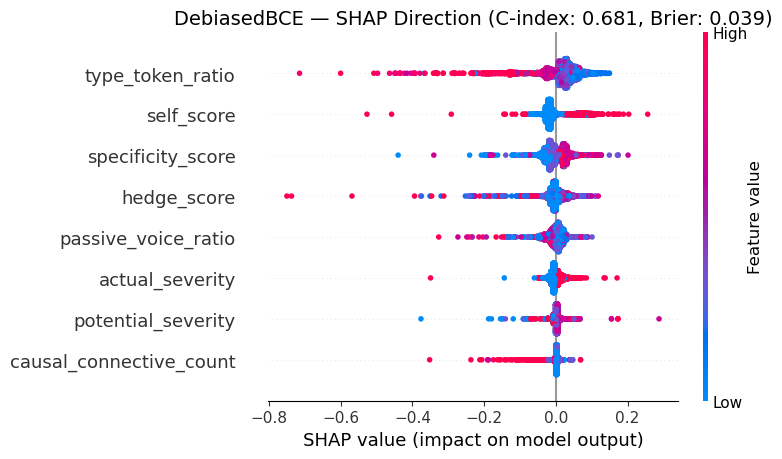

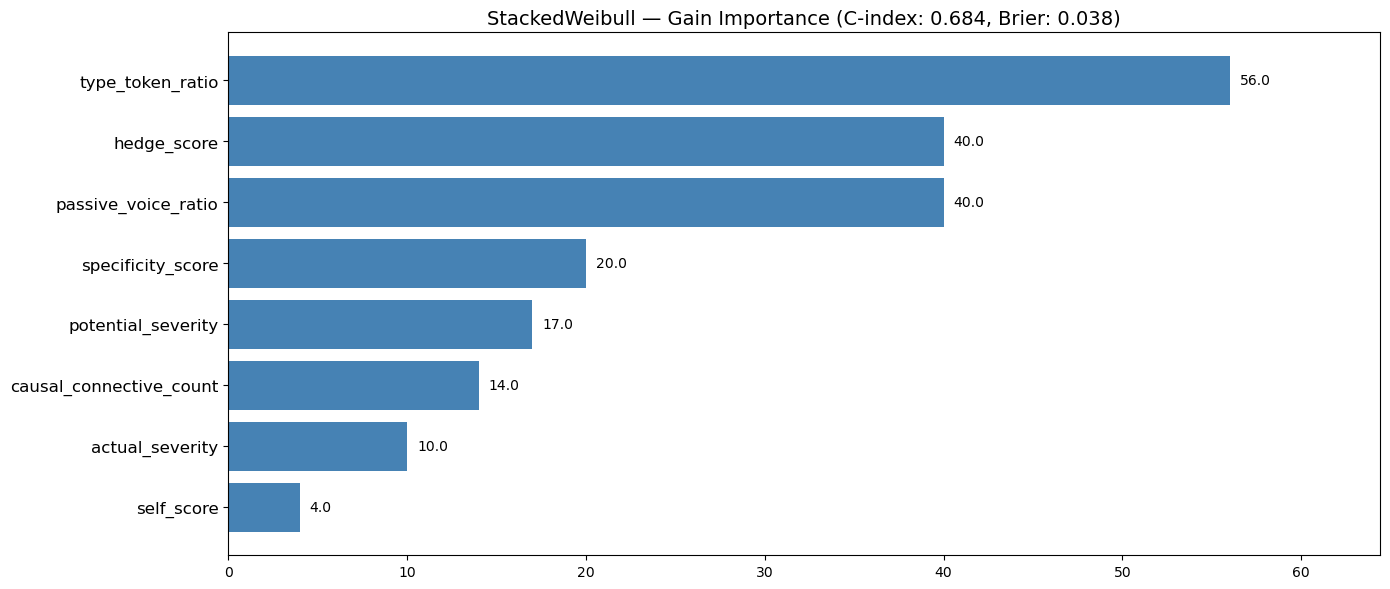

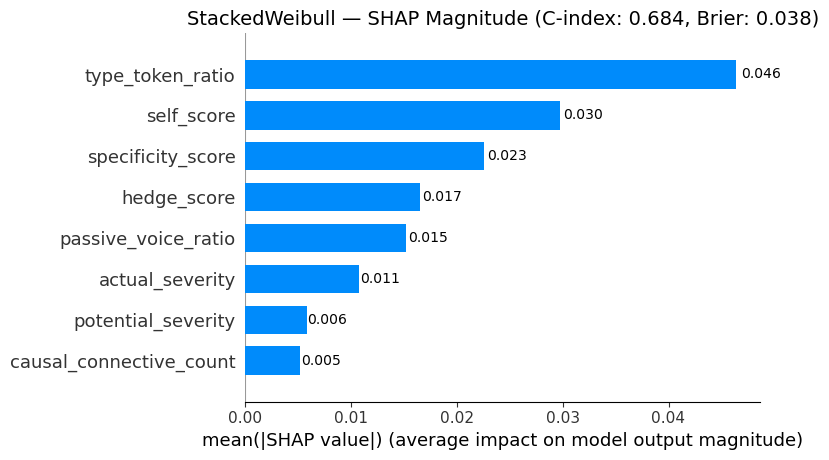

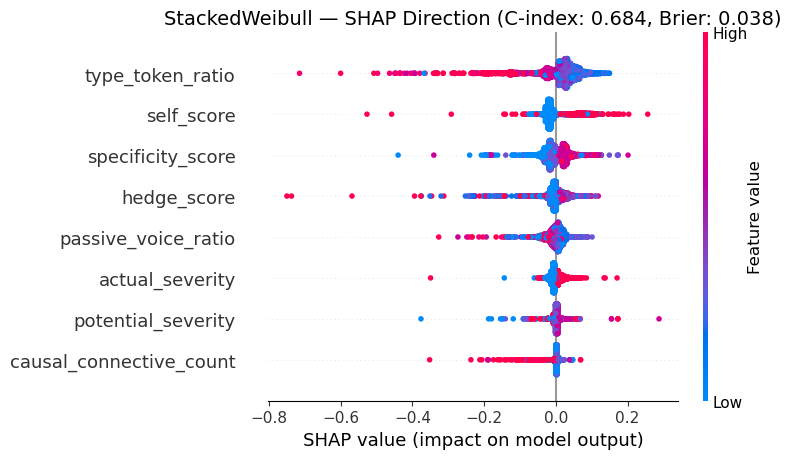

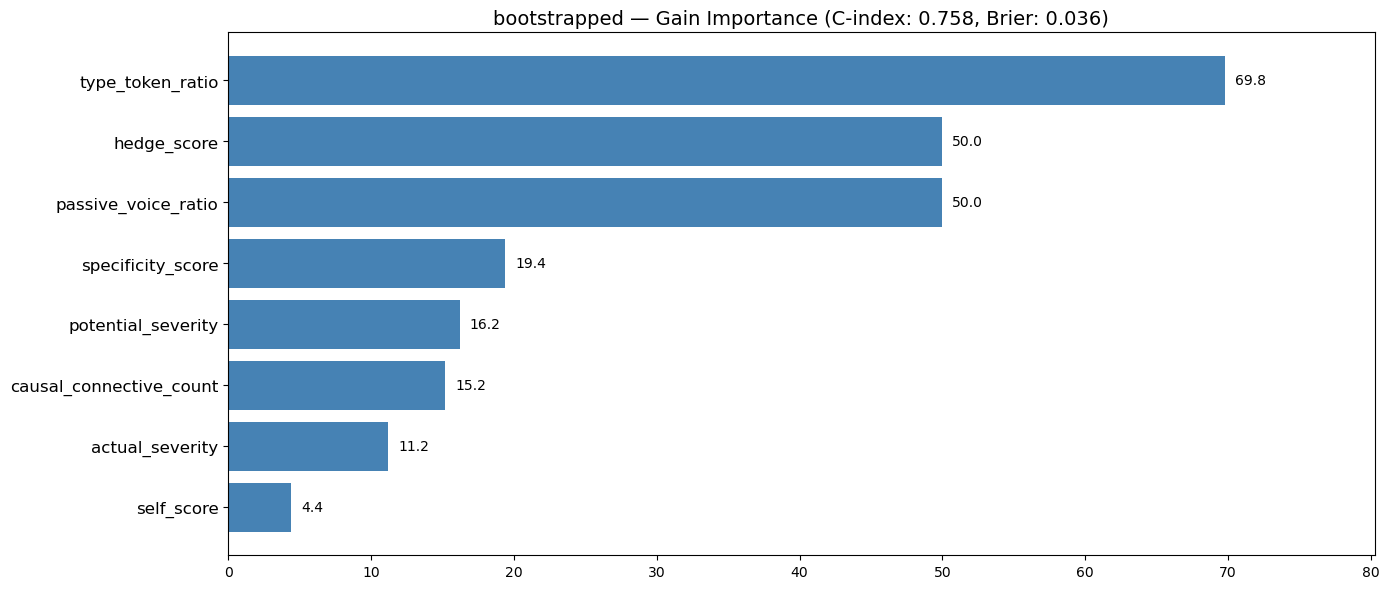

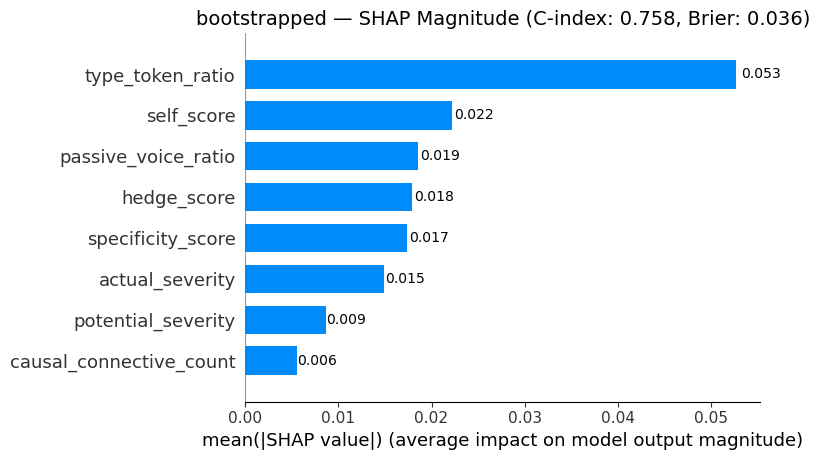

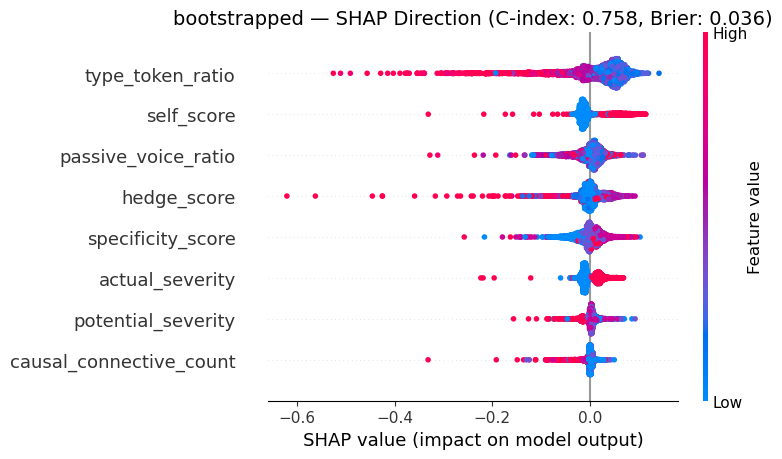

In [20]:
# Display Feature Imporrtances and SHAP plots for all XGB Models

# --- Build: model registry ---
models = {
    'KaplanNeighbors': kaplan_xgbse_model,
    'DebiasedBCE': debiased_xgbse_model,
    'StackedWeibull': stacked_xgbse_model,
    'bootstrapped': bootstrapped_xgbse_model,
}

# --- Build: metrics (C-index, Brier) for each model ---
metrics = {}
for name, model in models.items():
    preds = model.predict(X_val)
    c_index = concordance_index(y_val, preds)
    brier = approx_brier_score(y_val, preds)
    metrics[name] = {'c_index': c_index, 'brier': brier}

# --- Build: feature importances for each model ---
single_fit_models = {
    'KaplanNeighbors': kaplan_xgbse_model,
    'DebiasedBCE': debiased_xgbse_model,
    'StackedWeibull': stacked_xgbse_model,
}

feature_importances = {}
for name, model in single_fit_models.items():
    feature_importances[name] = model.feature_importances_

# bootstrapped — average across its 5 bootstrap estimators
bootstrap_importances = []
for est in bootstrapped_xgbse_model.estimators_:
    bootstrap_importances.append(est.feature_importances_)
feature_importances['bootstrapped'] = pd.DataFrame(bootstrap_importances).fillna(0).mean().to_dict()

# --- Rebuild: SHAP values for each model ---
shap_values_dict = {}

for name, model in single_fit_models.items():
    explainer = shap.TreeExplainer(model.feature_extractor.bst)
    shap_values_dict[name] = explainer.shap_values(X_val)

# bootstrapped — average across its 5 bootstrap estimators
bootstrap_shap_values = []
for est in bootstrapped_xgbse_model.estimators_:
    explainer = shap.TreeExplainer(est.feature_extractor.bst)
    bootstrap_shap_values.append(explainer.shap_values(X_val))
shap_values_dict['bootstrapped'] = np.mean(bootstrap_shap_values, axis=0)

# --- Plotting loop ---
for name, sv in shap_values_dict.items():
    c_index = metrics[name]['c_index']
    brier = metrics[name]['brier']
    title_suffix = f"(C-index: {c_index:.3f}, Brier: {brier:.3f})"

    # --- Panel 1: Gain importance ---
    fig1, ax1 = plt.subplots(figsize=(14, 6))
    imp_series = pd.Series(feature_importances[name]).sort_values(ascending=True)
    bars = ax1.barh(imp_series.index, imp_series.values, color='steelblue')
    ax1.set_title(f"{name} — Gain Importance {title_suffix}", fontsize=14)
    ax1.tick_params(axis='y', labelsize=12)

    for bar, val in zip(bars, imp_series.values):
        ax1.text(bar.get_width() + (imp_series.max() * 0.01), bar.get_y() + bar.get_height()/2,
                  f'{val:.1f}', va='center', fontsize=10)
    ax1.set_xlim(0, imp_series.max() * 1.15)

    plt.tight_layout()
    plt.savefig(f'gain_importance_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # --- Panel 2: SHAP magnitude ---
    plt.figure(figsize=(14, 6))
    shap.summary_plot(sv, X_val, plot_type="bar", show=False)
    ax2 = plt.gca()

    for bar in ax2.patches:
        width = bar.get_width()
        ax2.text(width + (width * 0.01), bar.get_y() + bar.get_height()/2,
                  f'{width:.3f}', va='center', fontsize=10)

    plt.title(f"{name} — SHAP Magnitude {title_suffix}", fontsize=14)
    plt.tight_layout()
    plt.savefig(f'shap_magnitude_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # --- Panel 3: SHAP direction (beeswarm) ---
    plt.figure(figsize=(14, 8))
    shap.summary_plot(sv, X_val, show=False)
    plt.title(f"{name} — SHAP Direction {title_suffix}", fontsize=14)
    plt.tight_layout()
    plt.savefig(f'shap_direction_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Running the Analysis Again Using all Control Variables

### 5.1 Additional Data Cleaning

In [21]:
# Create a list of all categorical columns - need to use their dummy coded columns instead
drop_columns = [
    'acn',
    'word_count',
    'named_entity_count',
    'event_date',
    'narrative_text',
    'synopsis',
    'label_method',
    'anomaly_code',
    'location_id',
    'airport',
    'organizational_unit',
    'country',
    'state',
    'city',
    'airport_type',
    'aircraft_type',
    'reporter_function',
    'flight_phase',
    'FlightConditions',
    'Light',
    'Mission',
    'PrimaryProblem',
    'is_right_censored',
    'airport_ZZZ',
    'anomaly_GroundEvent/EncounterLossOfVLOS(UAS)',
    'anomaly_InflightEvent/EncounterFlyAway(UAS)',
    'airport_type_heliport',
    'phase_Downwind',
    'phase_ReturntoHome(UAS)',
    'phase_flightseveraldays'
]

# removing: word_count, named_entity_count, due to collinearity issues identified in correlation matrix
# removing the following due to very low frequency: airport_ZZZ 'anomaly_GroundEvent/EncounterLossOfVLOS(UAS)', 'anomaly_InflightEvent/EncounterFlyAway(UAS)',
# 'airport_type_heliport', 'phase_Downwind', 'phase_ReturntoHome(UAS)', 'phase_flightseveraldays'

# Have to filter out any ZZZ due to compromise of recurrence definition and shuffling with random seed 1
filtered_full_data = data[data['airport'] != 'ZZZ'].drop(columns = drop_columns).dropna(subset=['self_score', 'actual_severity', 'potential_severity', 'CrewSize'])

full_df = filtered_full_data.sample(frac=1,random_state=1)

summarize_dataframe(full_df)

,Data Type,Missing Values,Unique Values,count,mean,std,min,25%,50%,75%,max
hedge_score,float64,0,1342,10211.0,0.002901,0.004973,0.0000,0.0000,0.0000,0.004695,0.142857
passive_voice_ratio,float64,0,335,10211.0,0.178206,0.162056,0.0000,0.0556,0.1515,0.250000,1.000000
causal_connective_count,int64,0,14,10211.0,0.676232,1.132272,0.0000,0.0000,0.0000,1.000000,14.000000
specificity_score,float64,0,5,10211.0,0.300313,0.225344,0.0000,0.2500,0.2500,0.500000,1.000000
type_token_ratio,float64,0,3405,10211.0,0.545308,0.128984,0.2203,0.4545,0.5273,0.619150,1.000000
recurrence_flag,int64,0,2,10211.0,0.061404,0.240082,0.0000,0.0000,0.0000,0.000000,1.000000
days_to_recurrence,float64,0,44,10211.0,328.861718,86.791521,28.0000,365.0000,365.0000,365.000000,365.000000
self_score,float64,0,2,10211.0,0.201351,0.401030,0.0000,0.0000,0.0000,0.000000,1.000000
actual_severity,float64,0,5,10211.0,1.418274,0.552490,1.0000,1.0000,1.0000,2.000000,5.000000
potential_severity,float64,0,5,10211.0,3.525903,0.939914,1.0000,3.0000,4.0000,4.000000,5.000000


In [22]:
full_df.recurrence_flag.value_counts()

recurrence_flag
0    9584
1     627
Name: count, dtype: int64

In [23]:
full_train = full_df.head(round(10211*.8))
full_test = full_df.tail(round(10211*.2))

continuous_cols = [
    'causal_connective_count', 'CrewSize',  # counts
    'hedge_score', 'passive_voice_ratio', 'specificity_score', 'type_token_ratio',  # ratios
]

std_scaler = StandardScaler()

full_scaled_train = full_train.copy()
full_scaled_test = full_test.copy()

full_scaled_train[continuous_cols] = std_scaler.fit_transform(full_train[continuous_cols])
full_scaled_test[continuous_cols] = std_scaler.transform(full_test[continuous_cols])

### 5.2 Cox Proportional Hazard Model Using All Features

In [24]:
# Blocking this out as high multi-collinearity halts convergence
full_cph = CoxPHFitter(penalizer=0.1)   # Instantiate the class to create a cph object
full_cph.fit(full_scaled_train, 'days_to_recurrence', event_col='recurrence_flag')   # Fit the data to train the model
full_cph.print_summary()    # Have a look at the significance of the features

<lifelines.CoxPHFitter: fitted with 8169 total observations, 7668 right-censored observations>
             duration col = 'days_to_recurrence'
                event col = 'recurrence_flag'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 8169
number of events observed = 501
   partial log-likelihood = -4271.56
         time fit was run = 2026-07-22 19:42:27 UTC

---
                                                                           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                                                  
hedge_score                                                               -0.00      1.00      0.03           -0.05            0.05                0.95                1.05
passive_voice_ratio                                                        0.01      1.01      0.03           -0.04            0.07                0.96                1.07
causal_connective_count                                                   -0.01      0.99      0.03           -0.07            0.04                0.93                1.04
specificity_score                                                         -0.04      0.96      0.03           -0.09            0.02                0.91                1.02
type_token_ratio                                                           0.06      1.06      0.03            0.00            0.11                1.00                1.12
self_score                                                                -0.11      0.89      0.07           -0.25            0.03                0.78                1.03
actual_severity                                                           -0.04      0.97      0.05           -0.14            0.07                0.87                1.07
potential_severity                                                        -0.00      1.00      0.03           -0.06            0.06                0.94                1.06
anomaly_ATCIssueAllTypes                                                  -0.01      0.99      0.06           -0.13            0.10                0.87                1.11
anomaly_AircraftEquipmentProblemCritical                                  -0.30      0.74      0.20           -0.68            0.08                0.50                1.09
anomaly_AircraftEquipmentProblemLessSevere                                -0.11      0.90      0.09           -0.27            0.06                0.76                1.07
anomaly_AirspaceViolationAllTypes                                         -0.16      0.85      0.12           -0.38            0.07                0.68                1.07
anomaly_ConflictAirborneConflict                                          -0.02      0.98      0.09           -0.20            0.17                0.82                1.18
anomaly_ConflictGroundConflict                                            -0.15      0.86      0.11           -0.37            0.06                0.69                1.06
anomaly_ConflictNMAC                                                       0.09      1.10      0.08           -0.07            0.25                0.94                1.28
anomaly_Critical                                                          -0.09      0.92      0.12           -0.33            0.15                0.72                1.16
anomaly_Deviation-AltitudeCrossingRestrictionNotMet                       -0.20      0.82      0.18           -0.55            0.14                0.58                1.15
anomaly_Deviation-AltitudeExcursionFromAssignedAltitude                   -0.31      0.73      0.11           -0.54           -0.09                0.58                0.91
anomaly_Deviation-AltitudeOvershoot                                       -0.26      0.77      0.14           -

In [25]:
full_scaled_test_Labels = convert_to_structured(full_scaled_test['days_to_recurrence'], full_scaled_test['recurrence_flag'])

full_scaled_pred = full_cph.predict_survival_function(full_scaled_test)

print(f'C-index: {concordance_index(full_scaled_test_Labels, full_scaled_pred.T)}')
print(f'Avg. Brier Score: {approx_brier_score(full_scaled_test_Labels, full_scaled_pred.T)}')

C-index: 0.8021596094661997
Avg. Brier Score: 0.032599764802280634


/opt/conda/lib/python3.12/site-packages/xgbse/non_parametric.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return pd.DataFrame(C_exp).fillna(method="bfill").fillna(method="ffill").values


### 5.3 Tree Based Models Using All Features

In [26]:
full_trainData = full_df.drop(columns = ['days_to_recurrence','recurrence_flag']).head(round(10211*.8))

full_trainLabels = full_df[['days_to_recurrence','recurrence_flag']].head(round(10211*.8))

full_testData = full_df.drop(columns = ['days_to_recurrence','recurrence_flag']).tail(round(10211*.2))

full_testLabels = full_df[['days_to_recurrence','recurrence_flag']].tail(round(10211*.2))

scaler = MinMaxScaler()

full_trainData = pd.DataFrame(scaler.fit_transform(full_trainData), 
                         columns=full_trainData.columns)

full_testData = pd.DataFrame(scaler.transform(full_testData), 
                         columns=full_testData.columns)

full_X = full_trainData
full_y = convert_to_structured(full_trainLabels['days_to_recurrence'], full_trainLabels['recurrence_flag'])

full_X_val = full_testData
full_y_val = convert_to_structured(full_testLabels['days_to_recurrence'], full_testLabels['recurrence_flag'])

In [27]:
# fitting xgbse Kaplan Neighbors model

full_kaplan_xgbse_model = XGBSEKaplanNeighbors(n_neighbors=5)

full_kaplan_xgbse_model.fit(
    full_X, full_y,
    validation_data=(full_X_val, full_y_val),
    early_stopping_rounds=20, # Stops training if validation metric doesn't improve for 20 rounds
    verbose_eval=False  # Prints the evaluation metric on the validation set
)

# predicting
full_kaplan_preds = full_kaplan_xgbse_model.predict(full_X_val)

# # running metrics
print(f'C-index: {concordance_index(full_y_val, full_kaplan_preds)}')
print(f'Avg. Brier Score: {approx_brier_score(full_y_val, full_kaplan_preds)}')

/opt/conda/lib/python3.12/site-packages/xgbse/non_parametric.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return pd.DataFrame(C_exp).fillna(method="bfill").fillna(method="ffill").values


C-index: 0.5925881707877887
Avg. Brier Score: 0.041597454840883015


/opt/conda/lib/python3.12/site-packages/xgbse/non_parametric.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return pd.DataFrame(C_exp).fillna(method="bfill").fillna(method="ffill").values


In [28]:
# fitting xgbse Debiased BCE model

full_debiased_xgbse_model = XGBSEDebiasedBCE()
full_debiased_xgbse_model.fit(
    full_X, full_y,
    validation_data=(full_X_val, full_y_val),
    early_stopping_rounds=20,  # Stops training if validation metric doesn't improve for 20 rounds
    verbose_eval=False  # Prints the evaluation metric on the validation set
)

# predicting
full_debiased_preds = full_debiased_xgbse_model.predict(full_X_val)

# # running metrics
print(f'C-index: {concordance_index(full_y_val, full_debiased_preds)}')
print(f'Avg. Brier Score: {approx_brier_score(full_y_val, full_debiased_preds)}')

C-index: 0.7874261558597757
Avg. Brier Score: 0.036839835289168496


/opt/conda/lib/python3.12/site-packages/xgbse/non_parametric.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return pd.DataFrame(C_exp).fillna(method="bfill").fillna(method="ffill").values


In [29]:
# fitting xgbse Stacked Weibull model

full_stacked_xgbse_model = XGBSEStackedWeibull()
full_stacked_xgbse_model.fit(
    full_X, full_y,
    validation_data=(full_X_val, full_y_val),
    early_stopping_rounds=20,  # Stops training if validation metric doesn't improve for 20 rounds
    verbose_eval=False  # Prints the evaluation metric on the validation set
)

# predicting
full_stacked_preds = full_stacked_xgbse_model.predict(full_X_val)

# # running metrics
print(f'C-index: {concordance_index(full_y_val, full_stacked_preds)}')
print(f'Avg. Brier Score: {approx_brier_score(full_y_val, full_stacked_preds)}')

C-index: 0.7844060631787471
Avg. Brier Score: 0.041480954643166326


/opt/conda/lib/python3.12/site-packages/xgbse/non_parametric.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return pd.DataFrame(C_exp).fillna(method="bfill").fillna(method="ffill").values


## 6. Interpreting the Models with All Control Variables

### 6.1 Looking at Top Performing Model

In [30]:
# Getting Feature Importances only for the best performing model considering unsatisfactory performance

importances = full_debiased_xgbse_model.feature_importances_

with pd.option_context('display.max_rows', None):
    display(print(pd.Series(importances).sort_values(ascending=False)))

type_token_ratio                                                    20.0
passive_voice_ratio                                                 17.0
anomaly_Deviation/Discrepancy-ProceduralClearance                   10.0
hedge_score                                                          8.0
CrewSize                                                             7.0
airport_other                                                        7.0
potential_severity                                                   7.0
specificity_score                                                    6.0
anomaly_ConflictNMAC                                                 6.0
org_Tower                                                            5.0
anomaly_Deviation/Discrepancy-ProceduralFAR                          5.0
causal_connective_count                                              5.0
anomaly_AircraftEquipmentProblemLessSevere                           4.0
anomaly_InflightEvent/EncounterWeather/Turbulence  

None

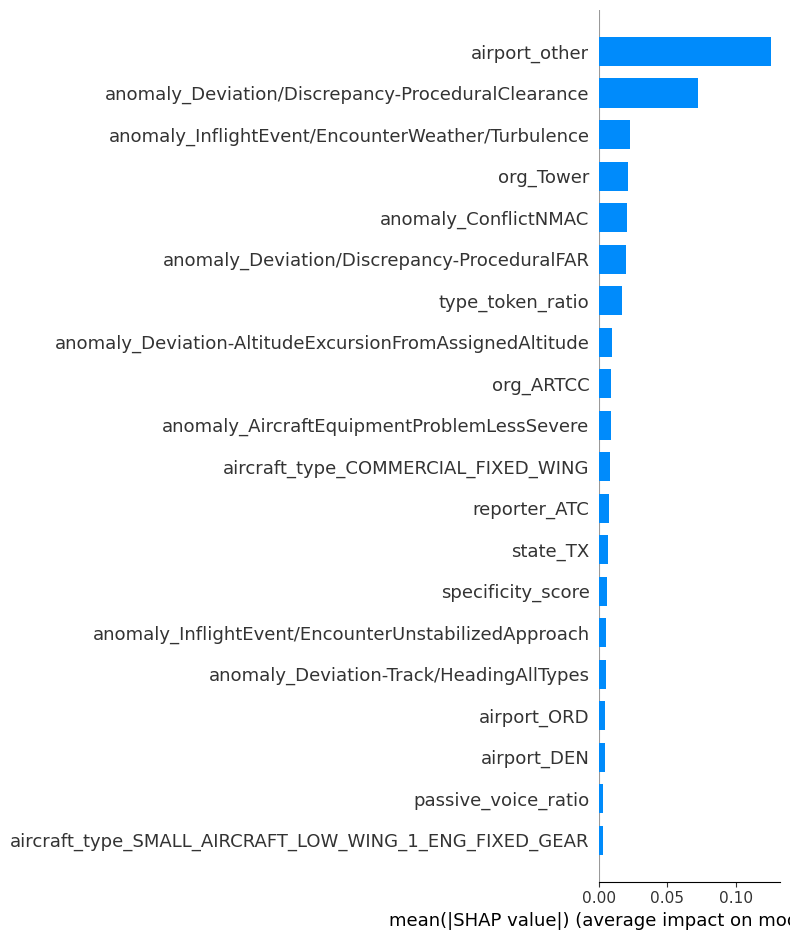

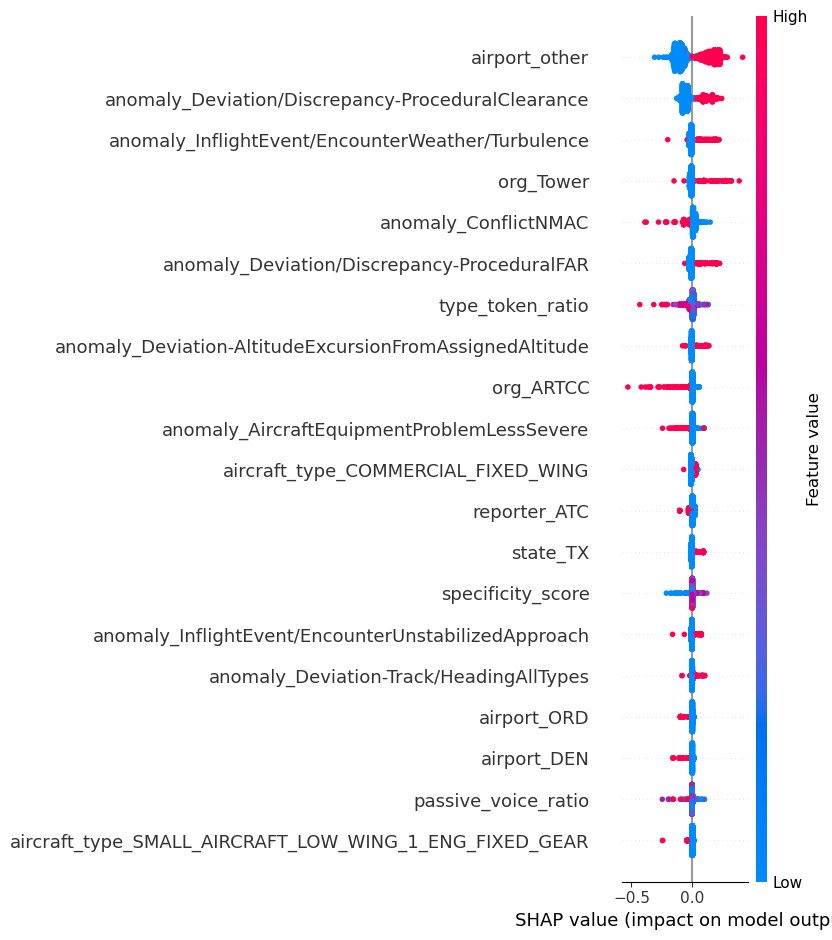

In [31]:
# Getting SHAP values only for the best performing model considering unsatisfactory performance

explainer = shap.TreeExplainer(full_debiased_xgbse_model.feature_extractor.bst)
shap_values = explainer.shap_values(full_X_val)

# Ranked magnitude (comparable to your gain importance table)
shap.summary_plot(shap_values, full_X_val, plot_type="bar")

# Full beeswarm — adds direction (does high hedge_score push risk up or down?)
shap.summary_plot(shap_values, full_X_val)

## 7. Post-Estimation Validations

In [32]:
# Proportional Hazard Test on cph

results = proportional_hazard_test(cph, scaled_train, time_transform='rank')
results.print_summary()

<lifelines.StatisticalResult: proportional_hazard_test>
    time_transform = rank
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 8916 total observations, 8368 right-censored observations>
         test_name = proportional_hazard_test

---
                         test_statistic    p  -log2(p)
actual_severity                    7.51 0.01      7.35
causal_connective_count            0.07 0.79      0.34
hedge_score                        0.35 0.55      0.85
passive_voice_ratio                1.07 0.30      1.74
potential_severity                 0.26 0.61      0.72
self_score                         3.13 0.08      3.70
specificity_score                  7.07 0.01      7.00
type_token_ratio                   0.01 0.90      0.15

In [33]:
# Proportional Hazard Test on full_cph

results = proportional_hazard_test(full_cph, full_scaled_train, time_transform='rank')
results.print_summary()

<lifelines.StatisticalResult: proportional_hazard_test>
    time_transform = rank
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 8169 total observations, 7668 right-censored observations>
         test_name = proportional_hazard_test

---
                                                                           test_statistic    p  -log2(p)
CrewSize                                                                             0.17 0.68      0.56
FlightConditions_IMC                                                                 0.30 0.58      0.78
FlightConditions_Marginal                                                            0.05 0.83      0.27
FlightConditions_Mixed                                                               0.31 0.58      0.79
FlightConditions_UNKNOWN                                                             0.30 0.59      0.77
FlightConditions_VMC                                                                 0.52 0.47      1.08
Light_Dawn                                                                           0.58 0.44      1.17
Light_Daylight                                                                       0.11 0.75      0.42
Light_Dusk                                                                           0.19 0.67      0.59
Light_Night                                                                          0.35 0.55      0.86
Light_UNKNOWN                                                                        0.00 0.96      0.06
Mission_Cargo / Freight / Delivery                                                   0.06 0.80      0.31
Mission_OTHER                                                                        0.23 0.63      0.67
Mission_Passenger                                                                    0.51 0.47      1.08
Mission_Personal                                                                     1.66 0.20      2.34
Mission_Training                                                                     0.59 0.44      1.18
Mission_UNKNOWN                                                                      0.72 0.40      1.34
PrimaryProblem_Aircraft                                                              0.05 0.83      0.27
PrimaryProblem_Human Factors                                                         0.05 0.83      0.28
PrimaryProblem_OTHER                                                                 0.01 0.94      0.09
PrimaryProblem_Procedure                                                             0.26 0.61      0.70
PrimaryProblem_Weather                                                               5.05 0.02      5.34
actual_severity                                                                      0.83 0.36      1.47
aircraft_type_A300                                                                   0.00 0.99      0.01
aircraft_type_A319                                                                   0.02 0.88      0.19
aircraft_type_A320                                                                   2.04 0.15      2.71
aircraft_type_A321                                                                   0.93 0.34      1.58
aircraft_type_A330                                                                   0.72 0.40      1.33
aircraft_type_AIRBUS_INDUSTRIE_UNDIFFERENTIATED_OR_OTHER_MODEL                       0.26 0.61      0.71
aircraft_type_AIRLINER_99                                                            0.00 0.95      0.08
aircraft_type_AMATEUR_HOME_BUILT_EXPERIMENTAL                                        0.99 0.32      1.65
aircraft_type_B737_700                                                               0.38 0.54      0.90
aircraft_type_B737_800                                                               0.05 0.81      0.30
aircraft_type_B737_900                                                               0.41 0.52      0.93
aircraft_type_B737_M